In [2]:
import pandas as pd
import numpy as np
import os
import warnings
import traceback
from scipy.optimize import minimize_scalar
from joblib import Parallel, delayed
os.environ['R_HOME'] = 'C:\\Program Files\\R\\R-4.4.1'
os.environ["PATH"] += os.pathsep + r"C:\Program Files\R\R-4.4.1\bin\x64"
from rpy2.robjects.packages import importr
from rpy2.robjects import Formula, pandas2ri
import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter
pandas2ri.activate()
warnings.filterwarnings('ignore')

def get_pathset(paths):
    return [os.path.join(dir, each_file) for dir, mid, files in os.walk(paths) for each_file in files if each_file.endswith(".wav")]

def get_keywords_dict(df):
    keywords_dict={}
    for each_ in df.values:
        sentenceID=each_[df.columns.get_loc("SentenceID")]
        if sentenceID not in keywords_dict:
            keywords_dict[sentenceID]=[]
        keyword=each_[df.columns.get_loc("Keyword")]
        if keyword not in keywords_dict[sentenceID]:
            keywords_dict[sentenceID].append(keyword)
    return dict(sorted(keywords_dict.items()))

def get_keywords_list(df):
    out_dict={}
    for each_ in df.values:
        keyword_loc=df.columns.get_loc("Keyword")
        key_word = each_[keyword_loc]
        sentenceID = each_[df.columns.get_loc("SentenceID")]
        if sentenceID not in out_dict.keys():
            out_dict[sentenceID]=[]
        if key_word not in out_dict[sentenceID]:
            out_dict[sentenceID].append(key_word)
    return out_dict

def get_exposure_set(feature_dict, df_all, trainingTalkerID, sentenceID, key_word):
    set1_list=[0,1,2,3,4,5,6,7,8,9,10,12,13,14,15,16]
    set2_list=[17,18,19,20,21,22,24,25,26,27,28,29,30,31,37,40]
    keywors_list = get_keywords_list(df_all)
    feats=[]
    for talker in trainingTalkerID:
        try:
            sentence_ind=(set1_list+set2_list).index(int(sentenceID[-3:])-1)
            key_word_ind=keywors_list[sentenceID].index(key_word)
            feats.append(feature_dict[talker][sentence_ind][key_word_ind])
        except:
            pass
    return feats

def get_test_feature(feature_dict, df_all, test_talker, sentenceID, key_word):
    set1_list=[0,1,2,3,4,5,6,7,8,9,10,12,13,14,15,16]
    set2_list=[17,18,19,20,21,22,24,25,26,27,28,29,30,31,37,40]
    keywors_list = get_keywords_list(df_all)
    sentence_ind=(set1_list+set2_list).index(int(sentenceID[-3:])-1)
    key_word_ind=keywors_list[sentenceID].index(key_word)
    return feature_dict[test_talker][sentence_ind][key_word_ind]

def get_training_paths(TrainingTalkerID):
    TalkerID=[]
    for each_ID in TrainingTalkerID.split(", "):
        if each_ID[:3]=="CMN":
            TalkerID.append(f"ALL_{each_ID[-3:]}_M_CMN")
        else:
            TalkerID.append(f"ALL_{each_ID[-3:]}_M_ENG")
    return TalkerID

from numba import njit
@njit
def cosine_distance(vec1, vec2):
    dot = 0.0
    norm1 = 0.0
    norm2 = 0.0
    for m in range(len(vec1)):
        dot += vec1[m] * vec2[m]
        norm1 += vec1[m]**2
        norm2 += vec2[m]**2
    if norm1 == 0 or norm2 == 0: return 1.0
    return 1.0 - (dot / ((norm1**0.5) * (norm2**0.5)))


@njit
def dtw_raw_distance(seq1, seq2, tau):
    n, m = len(seq1), len(seq2)
    dtw_matrix = np.full((n+1, m+1), np.inf)
    dtw_matrix[0, 0] = 0.0
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = cosine_distance(seq1[i-1], seq2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j], dtw_matrix[i, j-1], dtw_matrix[i-1, j-1])
    return dtw_matrix[n, m] / ((n + m) / 2)

def standardization(sentences):
    all_frames = [frame for sent in sentences for seg in sent for frame in seg]
    reduced = np.asarray(all_frames, dtype=np.float32)
    mu = reduced.mean(axis=0, keepdims=True)
    sd = reduced.std(axis=0, keepdims=True) + 1e-8
    reduced = (reduced - mu) / sd
    count = 0
    filled = [[] for _ in range(len(sentences))]
    for i, sent in enumerate(sentences):
        new_segs = []
        for seg in sent:
            T = seg.shape[0]
            new_segs.append(reduced[count:count+T])
            count += T
        filled[i] = new_segs
    return filled

def create_set(audio_dir, df, reduced_data):
    import textgrid
    set1_list=[0,1,2,3,4,5,6,7,8,9,10,12,13,14,15,16]
    set2_list=[17,18,19,20,21,22,24,25,26,27,28,29,30,31,37,40]
    
    keywords_dict=get_keywords_dict(df)
    keywords=[j for i in list(keywords_dict.values()) for j in i]
    audio_path=get_pathset(audio_dir)[::-1]
    out_dict={}
    word_features=[[] for i in range(len(keywords))]
    
    for __, each_path in enumerate(audio_path):
        current_talker=os.path.basename(each_path)[:13]
        if current_talker not in out_dict.keys():
            out_dict[current_talker]=[[] for i in range(32)]
        
        try:
            tg = textgrid.TextGrid.fromFile(each_path[:-3]+"TextGrid")
            tg_sentence = tg[0]
            for _,i in enumerate(tg[0]):
                if i.mark!="" and _ > 0: tg_sentence[_-1].maxTime=tg_sentence[_].minTime
            tg_sentence = [i for i in tg_sentence if i.mark!=""]
            tg_sentence=[tg_sentence[i] for i in set1_list+set2_list]
            tg_word = [i for i in tg[1] if i.mark!="" and i.mark!="sp"]
            
            count=0
            for _,each_sentence in enumerate(tg_sentence):
                sentence_total_length=each_sentence.maxTime-each_sentence.minTime
                for key_word in list(keywords_dict.values())[_]:
                    found=False
                    for each_word_tg in tg_word:
                        if each_word_tg.mark.lower()==key_word:
                            if each_word_tg.minTime >= each_sentence.minTime and each_word_tg.maxTime <= each_sentence.maxTime:
                                start=each_word_tg.minTime; end=each_word_tg.maxTime; found=True; break
                    
                    if found:
                        word_cut_start=start-each_sentence.minTime
                        word_cut_end=end-each_sentence.minTime
                        total_frames = reduced_data[_][__].shape[0]
                        word_start=round(total_frames * word_cut_start/sentence_total_length)
                        word_end=round(total_frames * word_cut_end/sentence_total_length)
                        features=reduced_data[_][__][word_start:word_end,:] 
                        word_features[count].append(features)
                        out_dict[current_talker][_].append(features)
                    count+=1
        except:
            continue
    return word_features, out_dict

def precompute_layer_distances(human_result_1a_split, audio_dir, reduced_data, tau, layer_name, func="mean"):
    word_features, feature_dict = create_set(audio_dir, human_result_1a_split, reduced_data)
    train_set_cache = {}
    test_word_cache = {}
    rows = []
    
    iterator = human_result_1a_split.to_dict('records')
    
    for row in iterator:
        kw = row["Keyword"]
        sent_id = row["SentenceID"]
        tr_ids = row["TrainingTalkerID"]
        test_file = os.path.basename(row["Filename"])[:13]
        trainingTalkerID = get_training_paths(tr_ids)
        
        cache_key = (tuple(sorted(trainingTalkerID)), sent_id, kw)
        if cache_key not in train_set_cache:
            train_feats = get_exposure_set(feature_dict, human_result_1a_split, trainingTalkerID, sent_id, kw)
            train_set_cache[cache_key] = train_feats
        else:
            train_feats = train_set_cache[cache_key]
            
        test_key = (test_file, sent_id, kw)
        if test_key not in test_word_cache:
            test_feat = get_test_feature(feature_dict, human_result_1a_split, test_file, sent_id, kw)
            test_word_cache[test_key] = test_feat
        else:
            test_feat = test_word_cache[test_key]

        dists = []
        for tr_feat in train_feats:
            if len(tr_feat) > 0 and len(test_feat) > 0:
                d = dtw_raw_distance(tr_feat, test_feat, tau)
                dists.append(d)
        
        if not dists: continue
            
        agg_dist = np.mean(dists)
        rows.append({
            'Keyword': kw, 'Condition2': row["Condition2"], 'TrainingTalkerID': tr_ids,
            'TestTalkerID': row["TestTalkerID"], 'SentenceID': sent_id, 'IsCorrect': row["IsCorrect"],
            'raw_distance': agg_dist, 'fold': row['fold']
        })
    return pd.DataFrame(rows)


In [3]:
import time
def process_single_layer_v4(layer_key, df_final, audio_dir, h5_path, tau=2):
    import pandas as pd
    import numpy as np
    import h5py
    import os
    from scipy.optimize import minimize_scalar
    import traceback
    import rpy2.robjects as ro
    from rpy2.robjects import pandas2ri
    from rpy2.robjects.packages import importr

    pandas2ri.activate()
    base   = importr('base')
    stats  = importr('stats')
    lme4   = importr('lme4')
    
    # 支持双向结构的灵活数据加载器
    def load_single_layer_from_h5(h5_path, audio_dir, layer_key):
        def get_pathset(paths):
            return [os.path.join(dir, each_file) for dir, mid, files in os.walk(paths) for each_file in files if each_file.endswith(".wav")]
        audio_paths = get_pathset(audio_dir)[::-1]
        speakers = [os.path.basename(p).replace(".wav", "") for p in audio_paths]
        set1_list = [0,1,2,3,4,5,6,7,8,9,10,12,13,14,15,16]
        set2_list = [17,18,19,20,21,22,24,25,26,27,28,29,30,31,37,40]
        combined_set = set1_list + set2_list
        
        layer_data = [ [] for _ in range(32) ]
        with h5py.File(h5_path, 'r') as h5f:
            root_keys = list(h5f.keys())
            # 自动探测结构: [layer][speaker][sentence] (t-SNE) 或 [speaker][sentence][layer] (原始特征)
            is_layer_first = layer_key in root_keys
            
            for s_idx_mapped, s_idx_original in enumerate(combined_set):
                sent_key = f"sentence_{s_idx_original:02d}"
                for spk in speakers:
                    if is_layer_first:
                        # 对应 xie21_tsne_3d.h5
                        feat = h5f[layer_key][spk][sent_key][:]
                    else:
                        # 对应 xie21_features.h5
                        feat = h5f[spk][sent_key][layer_key][:]
                    layer_data[s_idx_mapped].append(feat)
        return layer_data

    def run_glmm_logic(k, train_df, test_df, purpose='optimize'):
        try:
            train_work = train_df.copy()
            if 'TrainingTalkerID1' not in train_work.columns:
                train_work['TrainingTalkerID1'] = train_work['TrainingTalkerID'].apply(lambda x: ",".join(sorted(x.split(", "))))
            train_work['similarity'] = np.exp(-train_work['raw_distance'] * k)

            train_agg = train_work.groupby(
                ['Keyword', 'Condition2', 'TrainingTalkerID1', 'TestTalkerID', 'SentenceID'], as_index=False
            ).agg(
                IsCorrect=('IsCorrect', 'mean'), similarity=('similarity', 'mean'),
                numCorrect=('IsCorrect', lambda x: (x == 1).sum()), numIncorrect=('IsCorrect', lambda x: (x == 0).sum())
            )

            train_mean = train_agg['similarity'].mean()
            train_sd   = train_agg['similarity'].std()
            if train_sd == 0: return 999.0 if purpose == 'optimize' else None

            ro.globalenv['r_train'] = pandas2ri.py2rpy(train_agg)
            ro.r("""
                r_train$SentenceID   <- factor(r_train$SentenceID)
                r_train$Keyword      <- factor(r_train$Keyword)
                r_train$TestTalkerID <- factor(r_train$TestTalkerID)
                model_train <- glmer(
                    cbind(numCorrect, numIncorrect) ~ 1 + similarity + (1 | SentenceID / Keyword) + (1 | TestTalkerID),
                    data=r_train, family=binomial(link="logit"), control=glmerControl(optimizer="bobyqa", optCtrl=list(maxfun=10000)))
                z_train  <- summary(model_train)$coefficients[2, 3]
                ll_train <- as.numeric(logLik(model_train))
            """)
            z_train = ro.globalenv['z_train'][0]
            if purpose == 'optimize': return -z_train

            if purpose == 'evaluate' and test_df is not None:
                test_work = test_df.copy()
                if 'TrainingTalkerID1' not in test_work.columns:
                    test_work['TrainingTalkerID1'] = test_work['TrainingTalkerID'].apply(lambda x: ",".join(sorted(x.split(", "))))
                test_work['similarity'] = np.exp(-test_work['raw_distance'] * k)

                test_agg = test_work.groupby(['Keyword', 'Condition2', 'TrainingTalkerID1', 'TestTalkerID', 'SentenceID'], as_index=False).agg(
                    IsCorrect=('IsCorrect', 'mean'), similarity=('similarity', 'mean'),
                    numCorrect=('IsCorrect', lambda x: (x == 1).sum()), numIncorrect=('IsCorrect', lambda x: (x == 0).sum())
                )
                ro.globalenv['r_test'] = pandas2ri.py2rpy(test_agg)
                ro.r("""
                    r_test$SentenceID   <- factor(r_test$SentenceID)
                    r_test$Keyword      <- factor(r_test$Keyword)
                    r_test$TestTalkerID <- factor(r_test$TestTalkerID)
                    model_test <- glmer(
                        cbind(numCorrect, numIncorrect) ~ 1 + similarity + (1 | SentenceID / Keyword) + (1 | TestTalkerID),
                        data=r_test, family=binomial(link="logit"), control=glmerControl(optimizer="bobyqa", optCtrl=list(maxfun=10000)))
                    ll_test <- as.numeric(logLik(model_test))
                    z_test  <- summary(model_test)$coefficients[2, 3]
                """)
                return {
                    'z_train': z_train, 'z_test': ro.globalenv['z_test'][0],
                    'poll_train': ro.globalenv['ll_train'][0] / (train_agg['numCorrect'].sum() + train_agg['numIncorrect'].sum()),
                    'poll_test': ro.globalenv['ll_test'][0] / (test_agg['numCorrect'].sum() + test_agg['numIncorrect'].sum()),
                }
        except Exception:
            return 999.0 if purpose == 'optimize' else None
        return None

    try:
        layer_data = load_single_layer_from_h5(h5_path, audio_dir, layer_key)
        std_data = standardization(layer_data)
        df_dist  = precompute_layer_distances(df_final, audio_dir, std_data, tau, layer_key, func="mean")
        folds   = sorted(df_dist['fold'].unique())
        diagnostic_results, best_ks = [], []

        for f in folds:
            train_df = df_dist[df_dist['fold'] != f].copy()
            test_df  = df_dist[df_dist['fold'] == f].copy()
            res = minimize_scalar(lambda k: run_glmm_logic(k, train_df, None, 'optimize'), bounds=(0.001, 5.0), method='bounded')
            best_k = res.x
            best_ks.append(best_k)

            metrics = run_glmm_logic(best_k, train_df, test_df, 'evaluate')
            if metrics:
                diagnostic_results.append({
                    'layer': layer_key, 'fold': f, 'type': 'diagnostic', 'k': best_k,
                    'z_train': metrics['z_train'], 'z_test':  metrics['z_test'],
                    'poll_train': metrics['poll_train'], 'poll_test':  metrics['poll_test'],
                    'optimism': (metrics['poll_train'] - metrics['poll_test']) / abs(metrics['poll_train']),
                })

        mean_k = np.mean(best_ks)
        corrected_results = []
        for f in folds:
            train_df = df_dist[df_dist['fold'] != f].copy()
            test_df  = df_dist[df_dist['fold'] == f].copy()
            metrics = run_glmm_logic(mean_k, train_df, test_df, 'evaluate')
            if metrics:
                corrected_results.append({
                    'layer': layer_key, 'fold': f, 'type': 'corrected', 'k': mean_k,
                    'z_train': metrics['z_train'], 'z_test':  metrics['z_test'],
                    'poll_train': metrics['poll_train'], 'poll_test':  metrics['poll_test'],
                    'optimism': (metrics['poll_train'] - metrics['poll_test']) / abs(metrics['poll_train']),
                })

        results_df = pd.DataFrame(diagnostic_results + corrected_results)
        sim_df = df_dist[['Keyword', 'TrainingTalkerID', 'TestTalkerID', 'SentenceID', 'raw_distance']].copy()
        sim_df['similarity'] = np.exp(-sim_df['raw_distance'] * mean_k)
        sim_df = sim_df.drop(columns=['raw_distance']).drop_duplicates(subset=['Keyword', 'TrainingTalkerID', 'TestTalkerID', 'SentenceID']).reset_index(drop=True)
        return results_df, layer_key, sim_df

    except Exception as e:
        return f"EXCEPTION in {layer_key}: {e}\n{traceback.format_exc()}"

def run_analysis_pipeline_v4(layers_list, df_final, audio_dir, h5_path, n_jobs=-1):
    print(f"Starting analysis for {len(layers_list)} layers: {layers_list} ...")
    start = time.time()
    
    tasks = [delayed(process_single_layer_v4)(k, df_final, audio_dir, h5_path) for k in layers_list]
    raw_results = Parallel(n_jobs=n_jobs, verbose=5)(tasks)

    valid_results, similarity_frames = [], {}
    for item in raw_results:
        if isinstance(item, str):
            print(item)
            continue
        if item is None: continue
        res_df, layer_key, sim_df = item
        if res_df is not None: valid_results.append(res_df)
        if sim_df is not None: similarity_frames[layer_key] = sim_df

    all_layers_results = pd.concat(valid_results, ignore_index=True) if valid_results else pd.DataFrame()
    df_all = df_final.copy()
    for layer_key, sim_df in similarity_frames.items():
        df_all = df_all.merge(sim_df.rename(columns={'similarity': layer_key}), on=['Keyword', 'TrainingTalkerID', 'TestTalkerID', 'SentenceID'], how='left')

    print(f"Done in {(time.time() - start):.2f}s")
    return all_layers_results, df_all



In [3]:
import h5py
import textgrid
import torchaudio
import torchaudio.transforms as T
import torch
from sklearn.model_selection import StratifiedKFold

audio_dir = r"../data/raw_data/xie21"
human_result_path = r"../data/raw_data/xie21/test.xlsx"

# 1. 准备 Human Data
human_result = pd.read_excel(human_result_path)
human_result_1a = human_result[human_result["Experiment"]=="1a"].copy()
human_result_1a["TrainingTalkerID1"] = human_result_1a["TrainingTalkerID"].astype(str).apply(lambda x: ",".join(sorted(x.split(", "))) if pd.notna(x) else x)

df = human_result_1a.copy()
participants = df[['WorkerID', 'TrainingTestSet', 'Condition2', 'TestTalkerID']].drop_duplicates().reset_index(drop=True)
participants['combined_key'] = participants['TrainingTestSet'].astype(str) + "_" + participants['Condition2'].astype(str) + "_" + participants['TestTalkerID'].astype(str)
skf = StratifiedKFold(n_splits=3, shuffle=True)
participants['fold'] = -1
for fold_idx, (train_index, test_index) in enumerate(skf.split(participants, participants['combined_key'])):
    participants.loc[test_index, 'fold'] = fold_idx + 1
df_final = df.merge(participants[['WorkerID', 'fold']], on='WorkerID', how='left')

# 2. 自动检测并获取所有的 Layer 名称
h5_path = "../preprocessing/xie21_features.h5"  # <--- 支持 xie21_tsne_3d.h5 或 xie21_features.h5
h5_path = "../preprocessing/xie21_tsne_3d.h5"
with h5py.File(h5_path, 'r') as h5f:
    root_keys = list(h5f.keys())
    # 探测结构以获取正确的层名称列表
    if 'cnn_6' in root_keys or 'tr_12' in root_keys:
        layers_list = root_keys  # 结构: [layer][speaker][sentence] (tSNE)
    else:
        first_spk = root_keys[0]
        first_sent = list(h5f[first_spk].keys())[0]
        layers_list = list(h5f[first_spk][first_sent].keys()) # 结构: [speaker][sentence][layer]

print(f"Found {len(layers_list)} layers to process: {layers_list}")

# 3. 运行 GLMM 主流线 
print("Running HuBERT Layer Analysis...")
all_layers_results_hubert, df_final_hubert = run_analysis_pipeline_v4(layers_list, df_final, audio_dir, h5_path, n_jobs=-1)



Found 18 layers to process: ['cnn_2', 'cnn_3', 'cnn_4', 'cnn_5', 'cnn_6', 'tr_0', 'tr_10', 'tr_12', 'tr_14', 'tr_16', 'tr_18', 'tr_2', 'tr_20', 'tr_22', 'tr_24', 'tr_4', 'tr_6', 'tr_8']
Running HuBERT Layer Analysis...
Starting analysis for 18 layers: ['cnn_2', 'cnn_3', 'cnn_4', 'cnn_5', 'cnn_6', 'tr_0', 'tr_10', 'tr_12', 'tr_14', 'tr_16', 'tr_18', 'tr_2', 'tr_20', 'tr_22', 'tr_24', 'tr_4', 'tr_6', 'tr_8'] ...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done  3 out of 18 | elapsed:  3.1min remaining: 15.7min
[Parallel(n_jobs=-1)]: Done  7 out of 18 | elapsed:  3.3min remaining:  5.2min
[Parallel(n_jobs=-1)]: Done 11 out of 18 | elapsed:  3.3min remaining:  2.1min
[Parallel(n_jobs=-1)]: Done 15 out of 18 | elapsed:  3.9min remaining:   46.5s
[Parallel(n_jobs=-1)]: Done 18 out of 18 | elapsed:  5.3min finished


Done in 317.69s


In [7]:
all_layers_results_hubert.to_csv("xie21_glmm_results_hubert.csv", index=False)

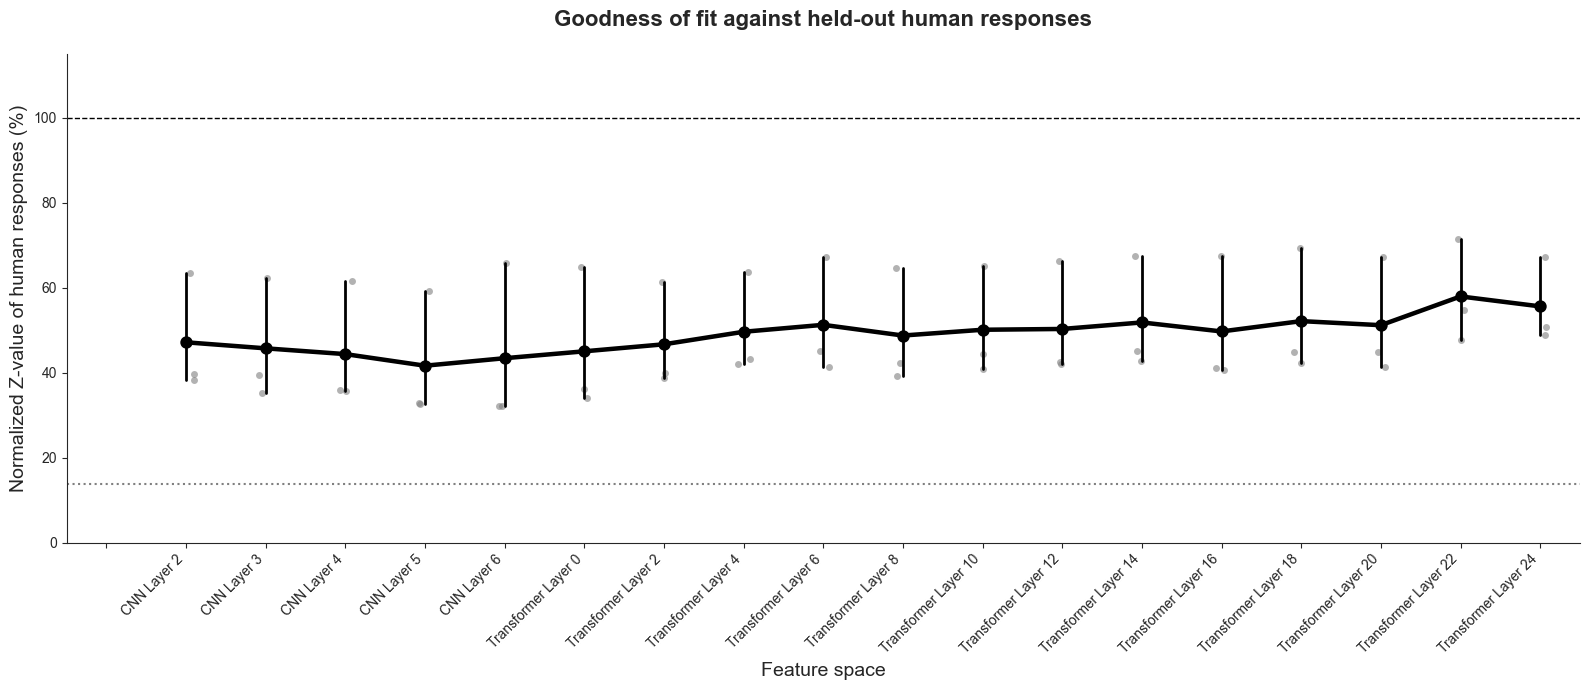

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 为了测试绘图，我们这里先仅仅画 HuBERT 的结果
df_viz_combined = all_layers_results_hubert.copy()
df_corr = df_viz_combined[df_viz_combined['type'] == 'corrected'].copy()

def format_label(l):
    if pd.isna(l): return l
    l_str = str(l)
    if l_str == 'MFCC': return 'MFCC'
    if l_str in ['STRFs', 'STRF']: return 'STRF'
    if l_str.startswith('tr_'): return f"Transformer Layer {l_str.split('_')[1]}"
    if l_str.startswith('cnn_'): return f"CNN Layer {l_str.split('_')[1]}"
    return l_str

df_corr['Feature space'] = df_corr['layer'].apply(format_label)
ceiling_vals = [15.5, 13.6, 13.5]
ceil_mean = np.mean(ceiling_vals)
df_corr['percent_ceiling'] = (df_corr['z_test'] / ceil_mean) * 100

def get_sort_key(l):
    if l == 'MFCC': return (0, 0)
    if l == 'STRF': return (0, 1)
    if '   ' in l: return (1, 0) 
    type_score = 2 if 'CNN' in l else 3
    nums = re.findall(r'\d+', l)
    num_score = int(nums[0]) if nums else 0
    return (type_score, num_score)

dummy_df = pd.DataFrame([{'Feature space': '   ', 'percent_ceiling': np.nan}])
df_corr = pd.concat([df_corr, dummy_df], ignore_index=True)

df_corr['sort_key'] = df_corr['Feature space'].apply(get_sort_key)
df_corr = df_corr.sort_values('sort_key')
order = df_corr['Feature space'].dropna().unique()

plt.figure(figsize=(16, 7))
sns.set_style("ticks")
sns.stripplot(data=df_corr, x='Feature space', y='percent_ceiling', order=order, color='gray', alpha=0.6, size=5, jitter=True, zorder=1)

network_mask = ~df_corr['Feature space'].isin(['MFCC', 'STRF', '   '])
if network_mask.any():
    sns.pointplot(data=df_corr[network_mask], x='Feature space', y='percent_ceiling', order=order, color='black', markers='o', scale=1.2, errorbar=('ci', 95), capsize=0, linestyle='-', err_kws={'linewidth': 2.0}, zorder=3)

plt.axhline(100, color='black', linestyle='--', linewidth=1.0, zorder=0)
significance_percent = (1.96 / ceil_mean) * 100
plt.axhline(significance_percent, color='gray', linestyle=':', linewidth=1.5, zorder=0)

plt.ylim(0, 115)
plt.ylabel("Normalized Z-value of human responses (%)", fontsize=14)
plt.xlabel("Feature space", fontsize=14)
plt.title("Goodness of fit against held-out human responses", fontsize=16, weight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.show()


Found 18 layers to process: ['cnn_2', 'cnn_3', 'cnn_4', 'cnn_5', 'cnn_6', 'tr_0', 'tr_10', 'tr_12', 'tr_14', 'tr_16', 'tr_18', 'tr_2', 'tr_20', 'tr_22', 'tr_24', 'tr_4', 'tr_6', 'tr_8']
Running HuBERT Layer Analysis...
Starting analysis for 18 layers: ['cnn_2', 'cnn_3', 'cnn_4', 'cnn_5', 'cnn_6', 'tr_0', 'tr_10', 'tr_12', 'tr_14', 'tr_16', 'tr_18', 'tr_2', 'tr_20', 'tr_22', 'tr_24', 'tr_4', 'tr_6', 'tr_8'] ...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done  3 out of 18 | elapsed:  4.7min remaining: 23.4min
[Parallel(n_jobs=-1)]: Done  7 out of 18 | elapsed:  5.4min remaining:  8.4min
[Parallel(n_jobs=-1)]: Done 11 out of 18 | elapsed:  5.9min remaining:  3.8min
[Parallel(n_jobs=-1)]: Done 15 out of 18 | elapsed:  7.8min remaining:  1.6min
[Parallel(n_jobs=-1)]: Done 18 out of 18 | elapsed: 10.1min finished


Done in 604.12s


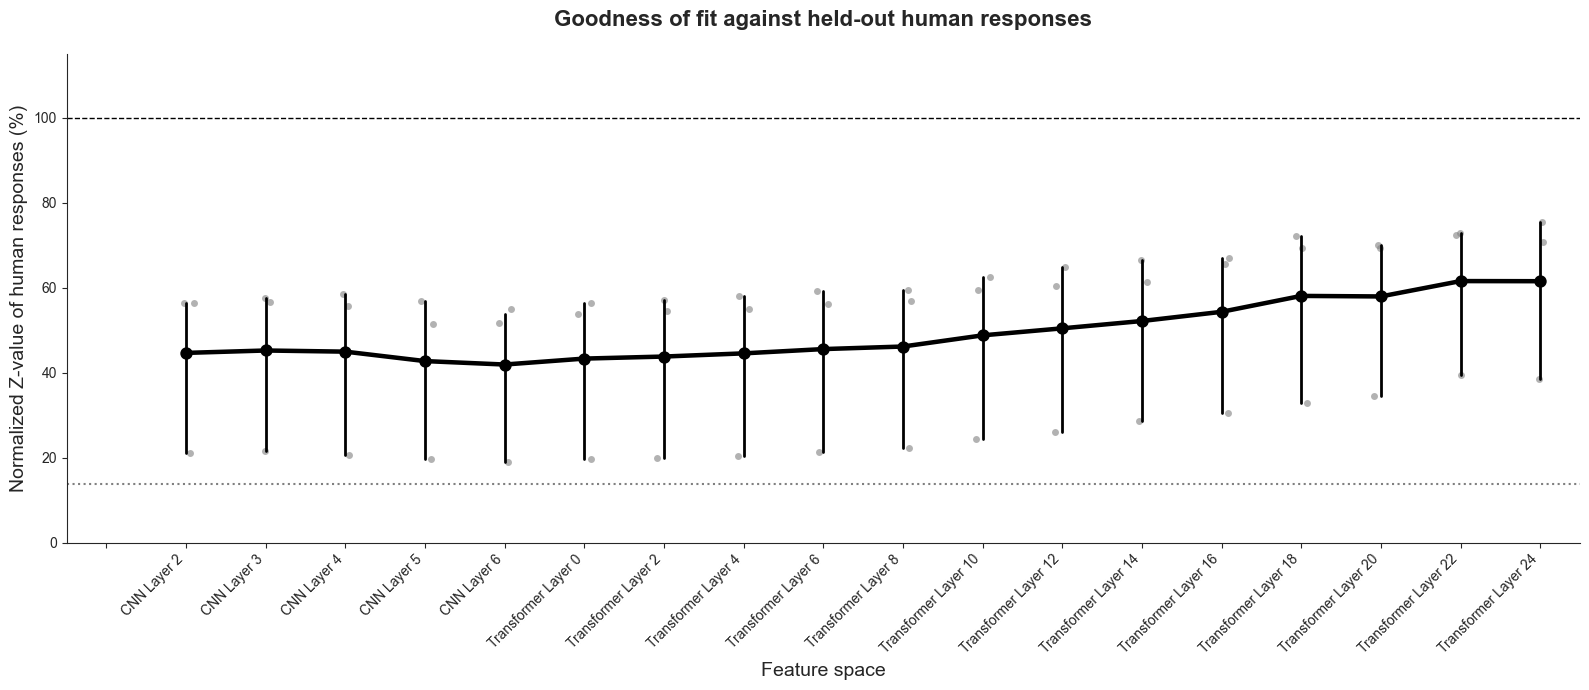

In [5]:
import h5py
import textgrid
import torchaudio
import torchaudio.transforms as T
import torch
from sklearn.model_selection import StratifiedKFold

audio_dir = r"../data/raw_data/xie21"
human_result_path = r"../data/raw_data/xie21/test.xlsx"

# 1. 准备 Human Data
human_result = pd.read_excel(human_result_path)
human_result_1a = human_result[human_result["Experiment"]=="1a"].copy()
human_result_1a["TrainingTalkerID1"] = human_result_1a["TrainingTalkerID"].astype(str).apply(lambda x: ",".join(sorted(x.split(", "))) if pd.notna(x) else x)

df = human_result_1a.copy()
participants = df[['WorkerID', 'TrainingTestSet', 'Condition2', 'TestTalkerID']].drop_duplicates().reset_index(drop=True)
participants['combined_key'] = participants['TrainingTestSet'].astype(str) + "_" + participants['Condition2'].astype(str) + "_" + participants['TestTalkerID'].astype(str)
skf = StratifiedKFold(n_splits=3, shuffle=True)
participants['fold'] = -1
for fold_idx, (train_index, test_index) in enumerate(skf.split(participants, participants['combined_key'])):
    participants.loc[test_index, 'fold'] = fold_idx + 1
df_final = df.merge(participants[['WorkerID', 'fold']], on='WorkerID', how='left')

h5_path = "../preprocessing/xie21_features_ft.h5"  # <--- 支持 xie21_tsne_3d.h5 或 xie21_features.h5
#h5_path = "../preprocessing/xie21_tsne_3d.h5"
with h5py.File(h5_path, 'r') as h5f:
    root_keys = list(h5f.keys())
    if 'cnn_6' in root_keys or 'tr_12' in root_keys:
        layers_list = root_keys
    else:
        first_spk = root_keys[0]
        first_sent = list(h5f[first_spk].keys())[0]
        layers_list = list(h5f[first_spk][first_sent].keys()) 

print(f"Found {len(layers_list)} layers to process: {layers_list}")

print("Running HuBERT Layer Analysis...")
all_layers_results_hubert_cos_full_dim_ft, df_final_hubert_full_dim_ft = run_analysis_pipeline_v4(layers_list, df_final, audio_dir, h5_path, n_jobs=-1)

all_layers_results_hubert_cos_full_dim_ft.to_csv("xie21_glmm_results_hubert_cos_full_dim_ft.csv", index=False)

import matplotlib.pyplot as plt
import seaborn as sns
import re

# 为了测试绘图，我们这里先仅仅画 HuBERT 的结果
df_viz_combined = all_layers_results_hubert_cos_full_dim_ft.copy()
df_corr = df_viz_combined[df_viz_combined['type'] == 'corrected'].copy()

def format_label(l):
    if pd.isna(l): return l
    l_str = str(l)
    if l_str == 'MFCC': return 'MFCC'
    if l_str in ['STRFs', 'STRF']: return 'STRF'
    if l_str.startswith('tr_'): return f"Transformer Layer {l_str.split('_')[1]}"
    if l_str.startswith('cnn_'): return f"CNN Layer {l_str.split('_')[1]}"
    return l_str

df_corr['Feature space'] = df_corr['layer'].apply(format_label)
ceiling_vals = [15.5, 13.6, 13.5]
ceil_mean = np.mean(ceiling_vals)
df_corr['percent_ceiling'] = (df_corr['z_test'] / ceil_mean) * 100

def get_sort_key(l):
    if l == 'MFCC': return (0, 0)
    if l == 'STRF': return (0, 1)
    if '   ' in l: return (1, 0) 
    type_score = 2 if 'CNN' in l else 3
    nums = re.findall(r'\d+', l)
    num_score = int(nums[0]) if nums else 0
    return (type_score, num_score)

dummy_df = pd.DataFrame([{'Feature space': '   ', 'percent_ceiling': np.nan}])
df_corr = pd.concat([df_corr, dummy_df], ignore_index=True)

df_corr['sort_key'] = df_corr['Feature space'].apply(get_sort_key)
df_corr = df_corr.sort_values('sort_key')
order = df_corr['Feature space'].dropna().unique()

plt.figure(figsize=(16, 7))
sns.set_style("ticks")
sns.stripplot(data=df_corr, x='Feature space', y='percent_ceiling', order=order, color='gray', alpha=0.6, size=5, jitter=True, zorder=1)

network_mask = ~df_corr['Feature space'].isin(['MFCC', 'STRF', '   '])
if network_mask.any():
    sns.pointplot(data=df_corr[network_mask], x='Feature space', y='percent_ceiling', order=order, color='black', markers='o', scale=1.2, errorbar=('ci', 95), capsize=0, linestyle='-', err_kws={'linewidth': 2.0}, zorder=3)

plt.axhline(100, color='black', linestyle='--', linewidth=1.0, zorder=0)
significance_percent = (1.96 / ceil_mean) * 100
plt.axhline(significance_percent, color='gray', linestyle=':', linewidth=1.5, zorder=0)

plt.ylim(0, 115)
plt.ylabel("Normalized Z-value of human responses (%)", fontsize=14)
plt.xlabel("Feature space", fontsize=14)
plt.title("Goodness of fit against held-out human responses", fontsize=16, weight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.show()


In [9]:
all_layers_results_hubert_full_dim

,layer,fold,type,k,z_train,z_test,poll_train,poll_test,optimism
0,cnn_2,1,diagnostic,3.090558,6.969995,6.446798,-0.237278,-0.312496,0.317006
1,cnn_2,2,diagnostic,3.090558,8.529309,4.109793,-0.240328,-0.297668,0.238588
2,cnn_2,3,diagnostic,1.862227,7.379788,5.629169,-0.246707,-0.286340,0.160648
3,cnn_2,1,corrected,2.681114,6.969995,6.446798,-0.237278,-0.312496,0.317006
4,cnn_2,2,corrected,2.681114,8.529309,4.109793,-0.240328,-0.297668,0.238588
...,...,...,...,...,...,...,...,...,...
103,tr_8,2,diagnostic,4.999996,8.529309,4.109793,-0.240328,-0.297668,0.238588
104,tr_8,3,diagnostic,4.999996,7.379751,5.629139,-0.246707,-0.286340,0.160648
105,tr_8,1,corrected,4.999996,6.969995,6.446798,-0.237278,-0.312496,0.317006
106,tr_8,2,corrected,4.999996,8.529309,4.109793,-0.240328,-0.297668,0.238588
